In [143]:
import os
import sys

current_dir = os.getcwd()

# If running from notebooks folder
project_root = os.path.abspath(os.path.join(current_dir, "..", "Project 2"))

if project_root not in sys.path:
    sys.path.append(project_root)

In [144]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [145]:
from src.preprocessing import (
    load_dataset,
    remove_duplicates,
    sort_dates,
    set_datetime_index,
    check_missing_values,
    resample_sales,
    perform_decomposition
)

In [146]:
csv_path = os.path.join(
    project_root,
    "data",
    "raw",
    "retail_sales.csv"
)

In [147]:
df = load_dataset(csv_path)

df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [148]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype         
---  ------    -----         
 0   date      datetime64[us]
 1   store_id  str           
 2   item_id   str           
 3   sales     int64         
 4   price     float64       
 5   promo     int64         
 6   weekday   int64         
 7   month     int64         
dtypes: datetime64[us](1), float64(1), int64(4), str(2)
memory usage: 342.4 MB


In [149]:
df.describe()

,date,sales,price,promo,weekday,month
count,4565000,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06,4.565000e+06
mean,2021-07-01 11:59:59.999999,2.926466e+01,5.399323e+01,9.999869e-02,3.001643e+00,6.523549e+00
min,2019-01-01 00:00:00,0.000000e+00,8.020000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,2020-04-01 00:00:00,1.800000e+01,3.197000e+01,0.000000e+00,1.000000e+00,4.000000e+00
50%,2021-07-01 12:00:00,2.700000e+01,5.352000e+01,0.000000e+00,3.000000e+00,7.000000e+00
75%,2022-10-01 00:00:00,3.800000e+01,7.536000e+01,0.000000e+00,5.000000e+00,1.000000e+01
max,2023-12-31 00:00:00,1.390000e+02,9.999000e+01,1.000000e+00,6.000000e+00,1.200000e+01
std,NaN,1.500996e+01,2.578461e+01,2.999983e-01,1.999315e+00,3.448534e+00


In [150]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 4565000
Columns : 8


In [151]:
df.columns

Index(['date', 'store_id', 'item_id', 'sales', 'price', 'promo', 'weekday',
       'month'],
      dtype='str')

In [152]:
check_missing_values(df)

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

In [153]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [154]:
df = remove_duplicates(df)

print(df.shape)

(4565000, 8)


In [155]:
df = sort_dates(df)

In [156]:
df = set_datetime_index(df)

df.head()

,store_id,item_id,sales,price,promo,weekday,month
date,,,,,,,
2019-01-01,store_1,item_1,41,21.30,0,1,1
2019-01-01,store_6,item_16,27,78.57,0,1,1
2019-01-01,store_39,item_26,47,31.60,0,1,1
2019-01-01,store_39,item_27,34,17.33,0,1,1
2019-01-01,store_39,item_28,19,35.23,1,1,1


In [157]:
print("Start Date :", df.index.min())
print("End Date :", df.index.max())

Start Date : 2019-01-01 00:00:00
End Date : 2023-12-31 00:00:00


In [158]:
date_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="D"
)

missing_dates = date_range.difference(df.index.unique())

print("Missing Dates:", len(missing_dates))

Missing Dates: 0


In [159]:
product_df = df[
    (df["store_id"] =="store_1") &
    (df["item_id"] == "item_1")
]

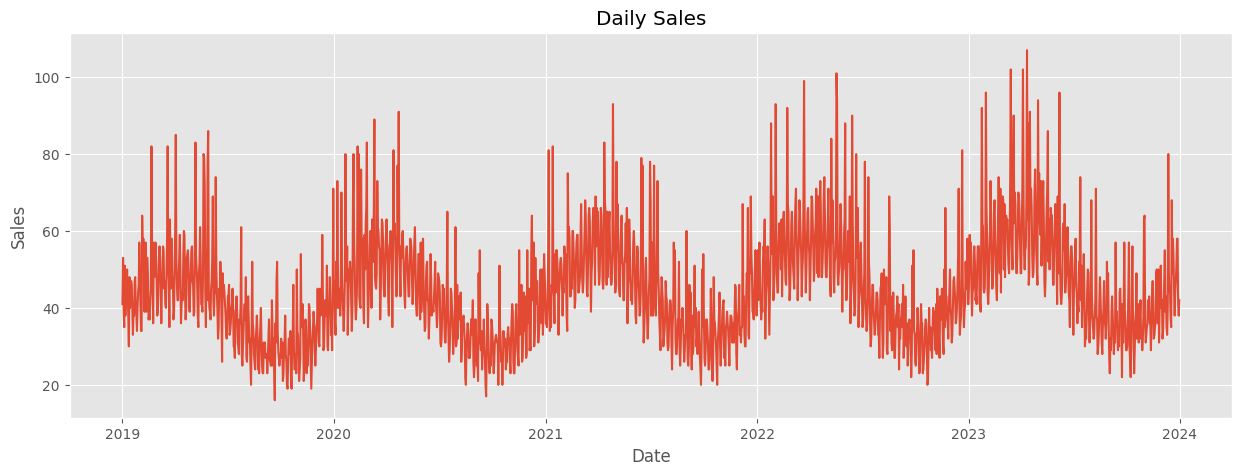

In [160]:
plt.figure(figsize=(15,5))

plt.plot(
    product_df.index,
    product_df["sales"]
)

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [161]:
weekly_sales = resample_sales(
    product_df,
    "W"
)

weekly_sales.head()

date
2019-01-06    257
2019-01-13    303
2019-01-20    291
2019-01-27    285
2019-02-03    306
Freq: W-SUN, Name: sales, dtype: int64

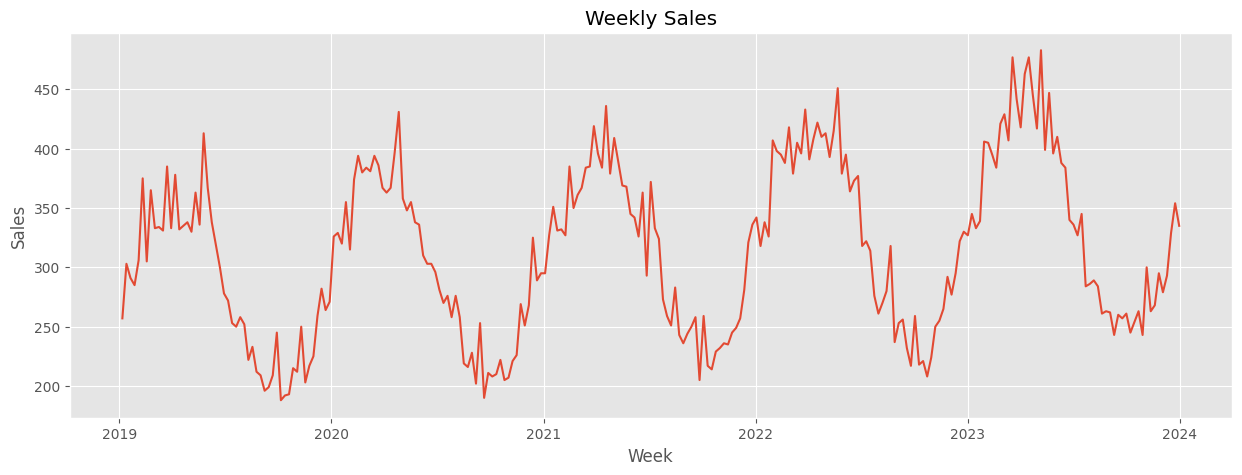

In [162]:
plt.figure(figsize=(15,5))

plt.plot(
    weekly_sales.index,
    weekly_sales
)

plt.title("Weekly Sales")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.show()

In [163]:
monthly_sales = resample_sales(
    product_df,
    "ME"
)

monthly_sales.head()

date
2019-01-31    1333
2019-02-28    1363
2019-03-31    1507
2019-04-30    1487
2019-05-31    1629
Freq: ME, Name: sales, dtype: int64

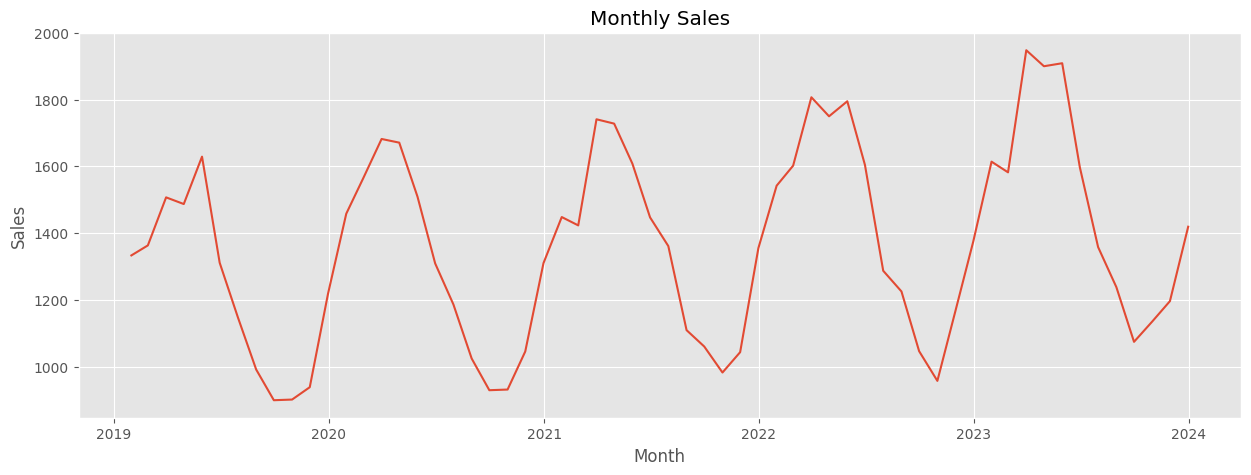

In [164]:
plt.figure(figsize=(15,5))

plt.plot(
    monthly_sales.index,
    monthly_sales
)

plt.title("Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

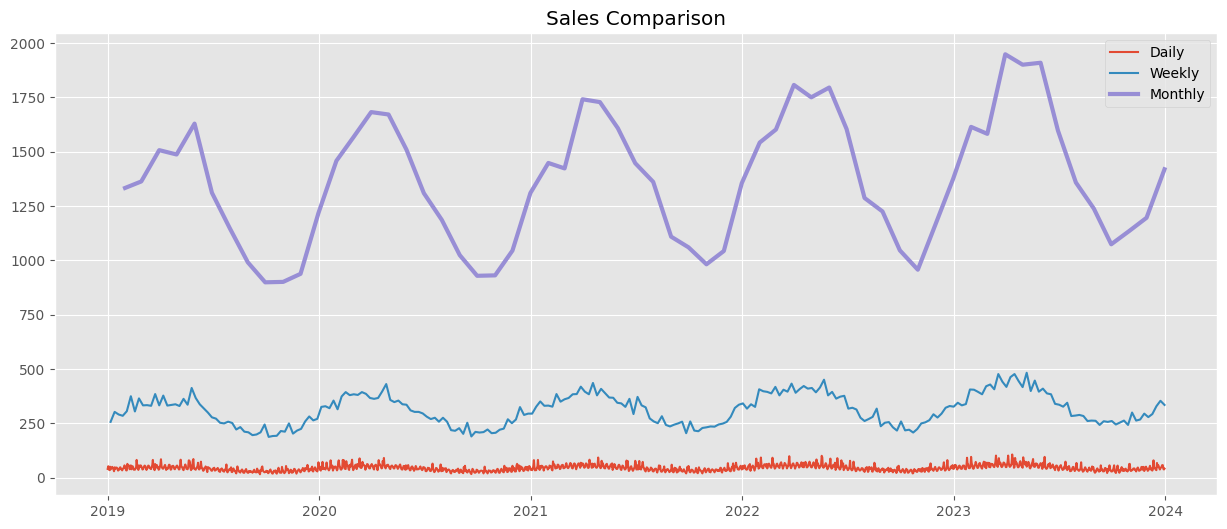

In [165]:
plt.figure(figsize=(15,6))

plt.plot(
    product_df.index,
    product_df["sales"],
    label="Daily"
)

plt.plot(
    weekly_sales.index,
    weekly_sales,
    label="Weekly"
)

plt.plot(
    monthly_sales.index,
    monthly_sales,
    linewidth=3,
    label="Monthly"
)

plt.legend()

plt.title("Sales Comparison")

plt.show()

In [166]:
decomposition = perform_decomposition(
    monthly_sales
)

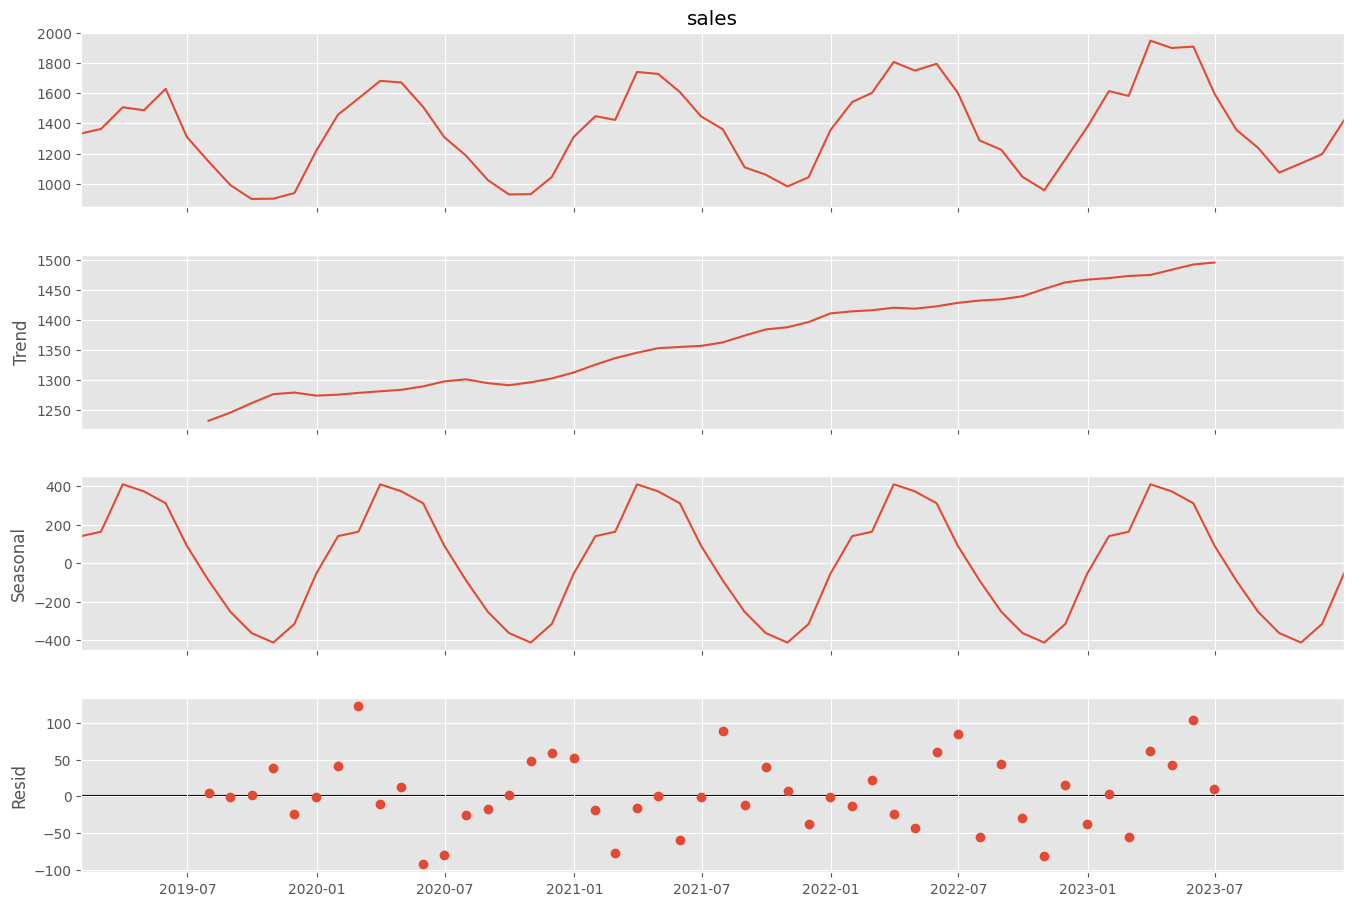

In [167]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

In [171]:
import os

processed_dir = os.path.join(project_root, "data", "processed")

os.makedirs(processed_dir, exist_ok=True)

output_path = os.path.join(
    processed_dir,
    "clean_sales.csv"
)

clean_df = product_df.reset_index()

clean_df.to_csv(
    output_path,
    index=False
)

In [172]:
clean_df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


# Conclusion

The supply chain dataset has been successfully preprocessed.

### Completed Tasks

- Loaded the raw dataset
- Inspected dataset structure
- Checked missing values
- Removed duplicate records
- Converted the date column to datetime
- Set the datetime index
- Selected a sample product for analysis
- Generated daily, weekly, and monthly sales trends
- Performed seasonal decomposition
- Saved the cleaned dataset for further analysis

The cleaned dataset is now ready for Week 2: Statistical Anomaly Detection.